# Entrenamiento del Modelo Final
## Predicción de Popularidad de Canciones de Spotify — Competencia Kaggle

Este notebook entrena el modelo final a partir de los datos de entrenamiento.
No incluye análisis exploratorio, comparación de modelos alternativos, ni
búsqueda de hiperparámetros — únicamente el código estrictamente necesario
para reproducir el modelo final.

**Input:** `base_train.csv`
**Output (en memoria, dentro de este mismo proceso):** Modelo A (ExtraTrees
general), Modelo B (ExtraTrees especializado en r&b), e imputador de valores
faltantes ajustado sobre train.

Nota: el modelo no se persiste en disco. El script de aplicación a test
(`aplicar_modelo_test.ipynb`) reentrena el modelo desde cero utilizando
exactamente la misma semilla aleatoria y los mismos hiperparámetros aquí
definidos, lo cual garantiza un resultado idéntico de forma determinística.


## 1. Imports y configuración

**Nota de reproducibilidad:** se fija `scikit-learn==1.6.1`. `ExtraTreesRegressor`
puede producir resultados ligeramente distintos entre versiones de scikit-learn
incluso con la misma semilla aleatoria, debido a cambios internos en la
implementación de la librería. Fijar la versión garantiza la reproducibilidad
exacta del modelo final.


In [46]:
import subprocess, sys
subprocess.check_call([sys.executable,"-m","pip","install","scikit-learn==1.6.1","-q","--break-system-packages"],
                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
for p in ["pandas","numpy"]:
    subprocess.check_call([sys.executable,"-m","pip","install",p,"-q","--break-system-packages"],
                          stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import ExtraTreesRegressor

import sklearn
print(f"scikit-learn version: {sklearn.__version__}")

SEED = 42


scikit-learn version: 1.6.1


## 2. Carga de datos de entrenamiento

In [47]:
train = pd.read_csv('base_train.csv', index_col=0)
print(f"Train cargado: {train.shape[0]} filas, {train.shape[1]} columnas")
val   = pd.read_csv('base_val.csv',   index_col=0)

print(f"Val:   {val.shape[0]} filas, {val.shape[1]} columnas")
print(f"Train index: {train.index.min()} a {train.index.max()}")
print(f"Val index:   {val.index.min()} a {val.index.max()}")

Train cargado: 26266 filas, 23 columnas
Val:   6567 filas, 22 columnas
Train index: 0 a 26265
Val index:   26266 a 32832


In [48]:
train.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,RElEdzDz0jD/AyKJjcfulWEzXE0kFpXmh4bXv+Y7ULB1Te...,FiHDRtJEUl5cyhTdIqc96pqUDrUK0HWRLp3DSgTddF8bq1...,brDyePD9ftuUV+4Gnr1FJsWPjK4BxX5b0XyoYraitMs=,66,bG4siwcYExux98rSemYk4gFXGxfOcnuI4eO5KJWxoMNQqX...,eEEakyxHF5aPFTwo7vH7PSLZS28a22sYpSK+vfnHtVI3oF...,2019-06-14,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,C/gTxHQyIA9QiUKErgUfcS4Hazv579AlBoZ9oLvF6cuICX...,VVXKCAduBRccYHLO3cxXaaipymdQo16Ux6Vzu25H+yN2su...,yZ+FAKQmScrq9x8PJ712bV8hv47jlgnsAewOoFrngIE=,67,zhxcdxW4y2Zb2lJW+s//k6WQalA+hkLiBWlF5/WAoXMCY4...,us9aGQxdufSLdUN2T+rgPBsZ+2/qXdflgy7Zpb2vbvEOgl...,2019-12-13,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,zBrCGicZsUMewr2V/Wzh/fQNTH+mcjXNtePfJoOLgW8VXo...,OJmKw9DdVmUNTSRf1s3zLsnfW31OCbcOjVR0sXbF2OBac5...,jRPX8GcEZVfskrG6YikLg2qg8eGMiDfMizo6LIIwvc8=,70,2RYXavv6fVc+05Zgc6gyfcrqO8sh2aZbIY1b/c92DzkWFU...,7ctdbmaBRIZois0jsmJ82vP9ILeLmx5gCptAHBSLdJvVpX...,2019-07-05,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,+MSXXbogejelwq6wZ+E3w/Zv3nh3umVA1H+Ab0GFp70Elg...,OO91MJrKuj8GvC77AJRFWCz9bnSn6h31C0A3ZvnDBv26Cd...,JkW2Ny6dCKXQSpNtt6h5SEw0R5NufDhLigaLODbIXbVck/...,60,1GmjrkRKyD4QwYDTPOPHmlqvED2VKimvsi4Jm7oINzYgjN...,KTVygB0VTKUZixMwz38GdnAvqHaNi/5jenecspqY++ON5Z...,2019-07-19,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,jCcYIsqs6knl1+5WHL596AZrxduU8BHVNtvgDIDqp8hV7D...,vWgNGqcABqdXJ9hywk5oxq6iA/19LHzD9y+zMPgPfjNciY...,OjmbI7NUKbIqRnUZvg8doB30B16uYkLaeJOyKeapbIQ=,69,WEzOSwMg+xGrI7s+7e7VrauNZgdXXvG8N5+VpQnf9MY9uH...,RSCivI2crYKMOE0dMQIgdZ2hAs0Llp38QdgFGBtu/9d6S8...,2019-03-05,1UeUqIlVAv/WzPy1CR7sm8pQ7buE50YX0hfKcbcxKkw=,R2xsImk7ArHWnrt5W4P7KfkBEFFPXX0SOT12gLJy28ev9t...,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [49]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
track_popularity,26266.0,44.543326,24.992724,0.000000,27.000000,48.000000,64.00000,100.000
danceability,26266.0,0.655715,0.149557,0.000000,0.559000,0.676000,0.76600,0.979
energy,26266.0,0.677818,0.179567,0.000175,0.560000,0.698000,0.81700,1.000
key,26266.0,5.377522,3.626019,0.000000,2.000000,6.000000,9.00000,11.000
loudness,26266.0,-6.983105,3.027421,-46.448000,-8.451000,-6.422000,-4.88525,1.275
mode,26266.0,0.577972,0.493892,0.000000,0.000000,1.000000,1.00000,1.000
speechiness,26266.0,0.111788,0.106399,0.000000,0.040400,0.063500,0.14300,0.918
acousticness,26266.0,0.193761,0.225929,0.000000,0.022825,0.102000,0.28800,0.994
instrumentalness,26266.0,0.054880,0.181430,0.000000,0.000000,0.000006,0.00125,0.994
liveness,26266.0,0.185227,0.149652,0.000000,0.092625,0.125000,0.23700,0.996


## 2. Análisis Exploratorio de Datos (EDA)

Esta sección analiza en profundidad la estructura del dataset, la calidad de
los datos, las distribuciones de las variables y la relación entre train y val,
antes de construir cualquier modelo.


### 2.1 Calidad de los datos: nulos y duplicados

In [50]:
print("=== Valores nulos en train ===")
nulls = train.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "Sin valores nulos en columnas numéricas/categóricas principales")
print()
print("=== Valores nulos en val ===")
nulls_val = val.isnull().sum()
print(nulls_val[nulls_val > 0] if nulls_val.sum() > 0 else "Sin valores nulos")
print()

print("=== Duplicados ===")
dup_train = train['track_id'].duplicated().sum()
dup_val = val['track_id'].duplicated().sum()
print(f"track_id duplicados en train: {dup_train} ({dup_train/len(train)*100:.1f}%)")
print(f"track_id duplicados en val:   {dup_val} ({dup_val/len(val)*100:.1f}%)")
print()
print("Nota: los duplicados probablemente corresponden a la misma canción apareciendo")
print("en múltiples playlists. No los eliminamos porque cada fila representa una")
print("observación válida (la canción en el contexto de esa playlist específica).")


=== Valores nulos en train ===
track_name          5
track_artist        5
track_album_name    5
dtype: int64

=== Valores nulos en val ===
Sin valores nulos

=== Duplicados ===
track_id duplicados en train: 3271 (12.5%)
track_id duplicados en val:   507 (7.7%)

Nota: los duplicados probablemente corresponden a la misma canción apareciendo
en múltiples playlists. No los eliminamos porque cada fila representa una
observación válida (la canción en el contexto de esa playlist específica).


### 2.2 Distribución de la variable objetivo: track_popularity

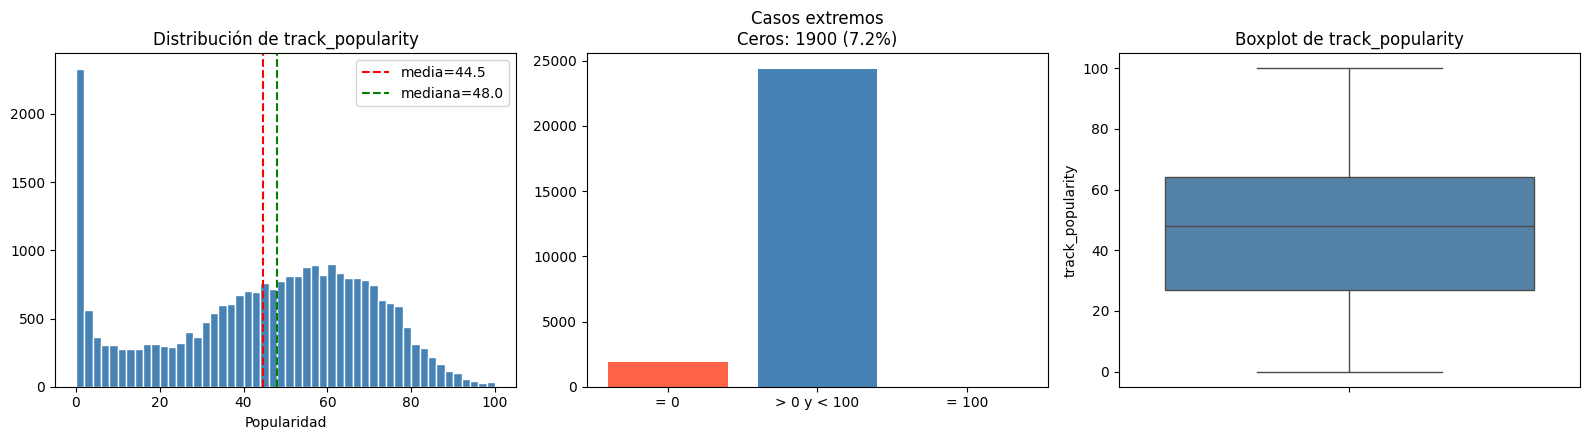

Media: 44.54  |  Mediana: 48.00
Desvío estándar: 24.99  |  Skewness: -0.342
Mínimo: 0  |  Máximo: 100


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(train['track_popularity'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train['track_popularity'].mean(), color='red', linestyle='--', label=f"media={train['track_popularity'].mean():.1f}")
axes[0].axvline(train['track_popularity'].median(), color='green', linestyle='--', label=f"mediana={train['track_popularity'].median():.1f}")
axes[0].set_title('Distribución de track_popularity')
axes[0].set_xlabel('Popularidad')
axes[0].legend()

ceros = (train['track_popularity']==0).sum()
axes[1].bar(['= 0', '> 0 y < 100', '= 100'],
            [ceros, ((train['track_popularity']>0)&(train['track_popularity']<100)).sum(), (train['track_popularity']==100).sum()],
            color=['tomato','steelblue','green'])
axes[1].set_title(f'Casos extremos\nCeros: {ceros} ({ceros/len(train)*100:.1f}%)')

sns.boxplot(y=train['track_popularity'], ax=axes[2], color='steelblue')
axes[2].set_title('Boxplot de track_popularity')

plt.tight_layout()
plt.show()

print(f"Media: {train['track_popularity'].mean():.2f}  |  Mediana: {train['track_popularity'].median():.2f}")
print(f"Desvío estándar: {train['track_popularity'].std():.2f}  |  Skewness: {train['track_popularity'].skew():.3f}")
print(f"Mínimo: {train['track_popularity'].min()}  |  Máximo: {train['track_popularity'].max()}")


### 2.3 Composición de géneros: train vs val

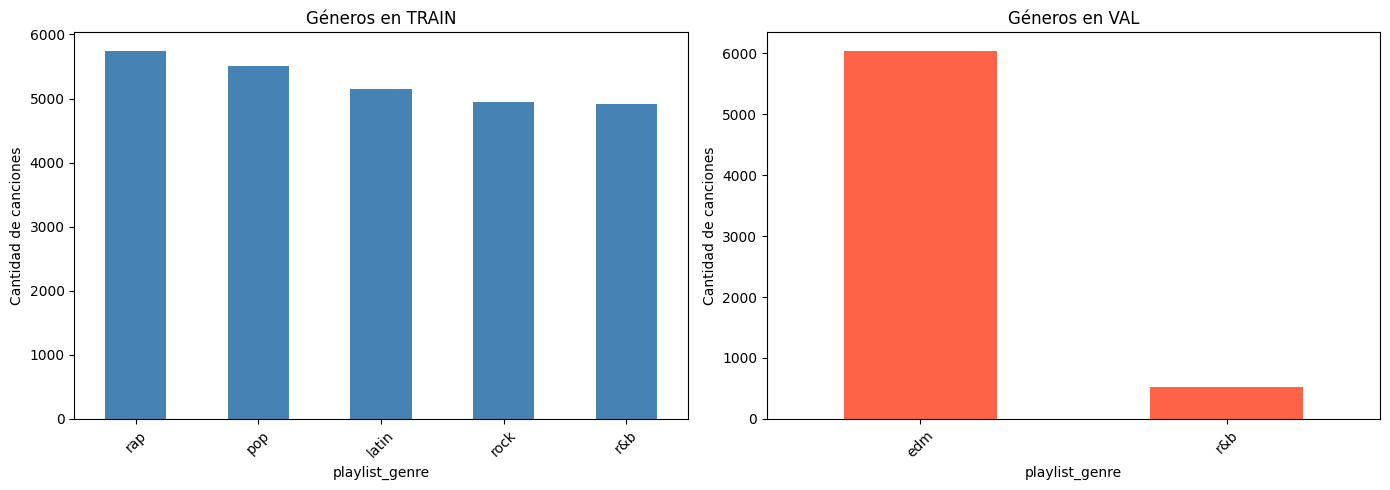

=== Géneros en TRAIN ===
playlist_genre
rap      5746
pop      5507
latin    5155
rock     4951
r&b      4907
Name: count, dtype: int64

=== Géneros en VAL ===
playlist_genre
edm    6043
r&b     524
Name: count, dtype: int64

Géneros solo en VAL (no en train):   {'edm'}
Géneros solo en TRAIN (no en val):   {'rap', 'pop', 'rock', 'latin'}
Géneros en común:                    {'r&b'}


In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train['playlist_genre'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Géneros en TRAIN')
axes[0].set_ylabel('Cantidad de canciones')
axes[0].tick_params(axis='x', rotation=45)

val['playlist_genre'].value_counts().plot(kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Géneros en VAL')
axes[1].set_ylabel('Cantidad de canciones')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("=== Géneros en TRAIN ===")
print(train['playlist_genre'].value_counts())
print()
print("=== Géneros en VAL ===")
print(val['playlist_genre'].value_counts())
print()

genres_train = set(train['playlist_genre'].unique())
genres_val   = set(val['playlist_genre'].unique())
print(f"Géneros solo en VAL (no en train):   {genres_val - genres_train}")
print(f"Géneros solo en TRAIN (no en val):   {genres_train - genres_val}")
print(f"Géneros en común:                    {genres_train & genres_val}")


### 2.4 Orden de las observaciones en val

In [53]:
genre_seq = val['playlist_genre'].values
changes = [(i, genre_seq[i-1], genre_seq[i]) for i in range(1, len(genre_seq)) if genre_seq[i] != genre_seq[i-1]]

print(f"Cantidad de cambios de género en la secuencia de val: {len(changes)}")
for c in changes:
    print(f"  Posición {c[0]} (índice {val.index[c[0]]}): {c[1]} → {c[2]}")
print()

rb_count = (val['playlist_genre']=='r&b').sum()
print(f"Las primeras {rb_count} filas de val son 100% r&b.")
print(f"Las siguientes {len(val)-rb_count} filas son 100% edm.")
print()
print("El archivo no está aleatorizado: las observaciones están agrupadas por género.")


Cantidad de cambios de género en la secuencia de val: 1
  Posición 524 (índice 26790): r&b → edm

Las primeras 524 filas de val son 100% r&b.
Las siguientes 6043 filas son 100% edm.

El archivo no está aleatorizado: las observaciones están agrupadas por género.


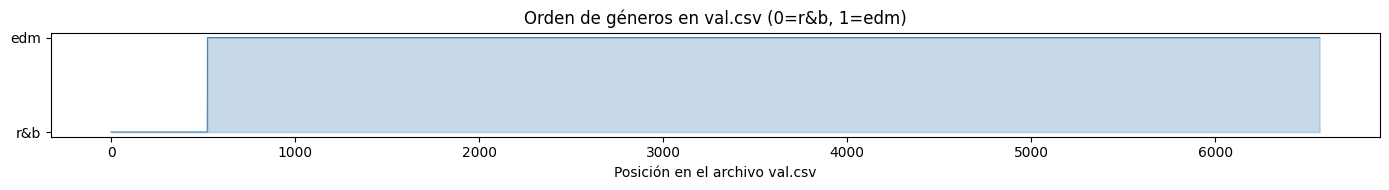

In [54]:
fig, ax = plt.subplots(figsize=(14, 2))
genre_numeric = (val['playlist_genre'] == 'edm').astype(int).values
ax.plot(range(len(genre_numeric)), genre_numeric, color='steelblue', linewidth=0.8)
ax.fill_between(range(len(genre_numeric)), genre_numeric, alpha=0.3, color='steelblue')
ax.set_yticks([0, 1])
ax.set_yticklabels(['r&b', 'edm'])
ax.set_xlabel('Posición en el archivo val.csv')
ax.set_title('Orden de géneros en val.csv (0=r&b, 1=edm)')
plt.tight_layout()
plt.show()


### 2.5 Subgéneros: otra capa del distribution shift

In [55]:
print(f"Subgéneros únicos en train: {train['playlist_subgenre'].nunique()}")
print(f"Subgéneros únicos en val:   {val['playlist_subgenre'].nunique()}")
print()

subg_train = set(train['playlist_subgenre'].unique())
subg_val   = set(val['playlist_subgenre'].unique())
print(f"Subgéneros presentes en val pero no en train:")
for s in (subg_val - subg_train):
    print(f"  - {s}")
print()
print("Los subgéneros de val no vistos en train son variantes de EDM")
print("(electro house, big room, etc.), consistente con que EDM es ausente de train.")


Subgéneros únicos en train: 20
Subgéneros únicos en val:   5

Subgéneros presentes en val pero no en train:
  - big room
  - progressive electro house
  - pop edm
  - electro house

Los subgéneros de val no vistos en train son variantes de EDM
(electro house, big room, etc.), consistente con que EDM es ausente de train.


### 2.6 Popularidad promedio por género (train)

                 mean  median    std  count
playlist_genre                             
pop             47.74    52.0  25.16   5507
latin           47.03    50.0  25.42   5155
rap             43.22    47.0  23.30   5746
r&b             42.74    46.0  25.80   4907
rock            41.73    46.0  24.83   4951


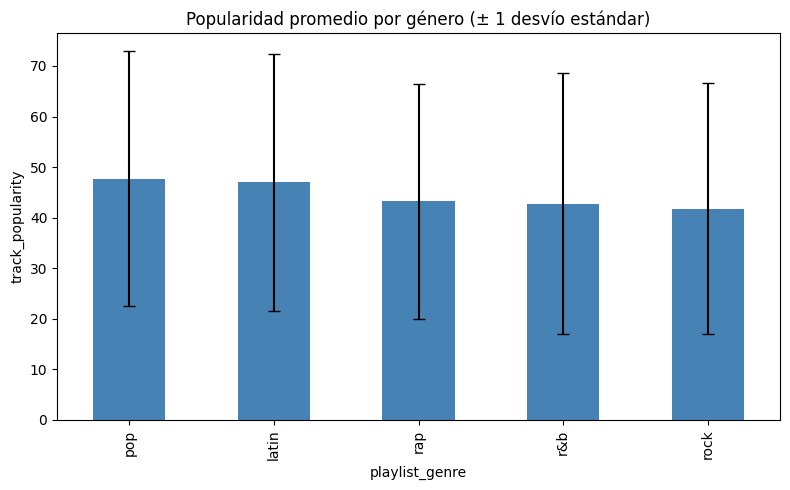

In [56]:
genre_stats = train.groupby('playlist_genre')['track_popularity'].agg(['mean','median','std','count']).round(2)
genre_stats = genre_stats.sort_values('mean', ascending=False)
print(genre_stats)

fig, ax = plt.subplots(figsize=(8, 5))
genre_stats['mean'].plot(kind='bar', yerr=genre_stats['std'], ax=ax, color='steelblue', capsize=4)
ax.set_title('Popularidad promedio por género (± 1 desvío estándar)')
ax.set_ylabel('track_popularity')
plt.tight_layout()
plt.show()


### 2.7 Perfil de audio por género — comparación de distribuciones

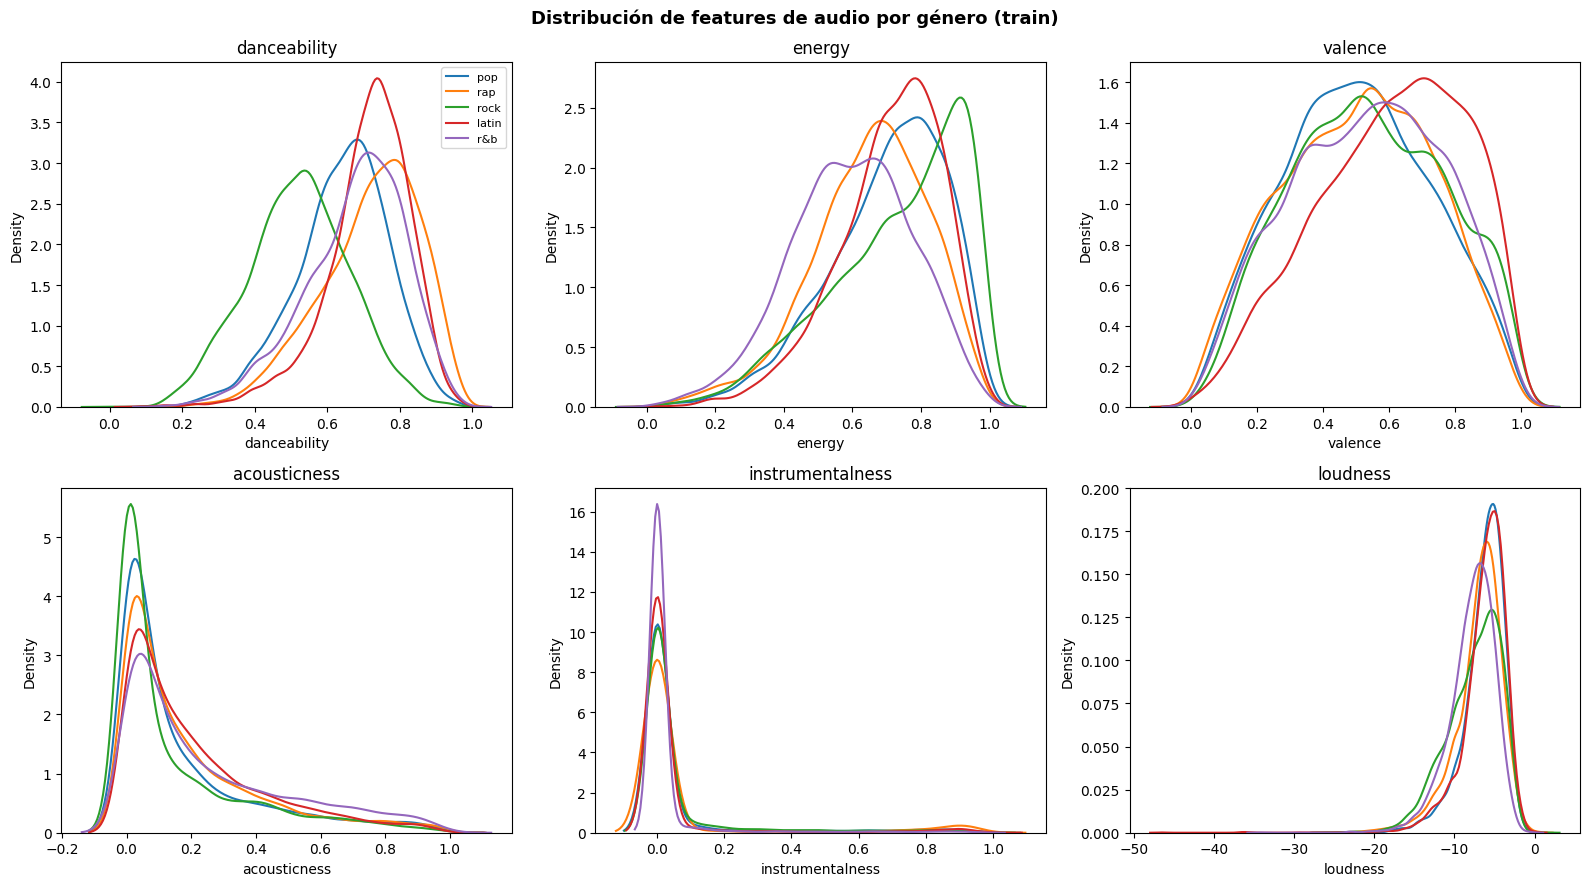

In [57]:
audio_cols_eda = ['danceability','energy','valence','acousticness','instrumentalness','loudness']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(audio_cols_eda):
    for genre in train['playlist_genre'].unique():
        sns.kdeplot(train[train['playlist_genre']==genre][col], ax=axes[i], label=genre, linewidth=1.5)
    axes[i].set_title(col)
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle('Distribución de features de audio por género (train)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [58]:
print("=== Perfil de audio promedio por género (train) ===")
print(train.groupby('playlist_genre')[audio_cols_eda].mean().round(3))


=== Perfil de audio promedio por género (train) ===
                danceability  energy  valence  acousticness  instrumentalness  \
playlist_genre                                                                  
latin                  0.713   0.708    0.606         0.211             0.044   
pop                    0.639   0.701    0.504         0.171             0.060   
r&b                    0.677   0.596    0.532         0.252             0.028   
rap                    0.718   0.651    0.505         0.192             0.076   
rock                   0.521   0.733    0.537         0.145             0.062   

                loudness  
playlist_genre            
latin             -6.264  
pop               -6.315  
r&b               -7.807  
rap               -7.042  
rock              -7.589  


### 2.8 Distancia del perfil de audio de cada género a EDM

Distancia euclidiana (en espacio de audio estandarizado) de cada género a EDM:
pop      1.182
latin    1.542
rock     1.632
rap      1.816
r&b      1.983
dtype: float64


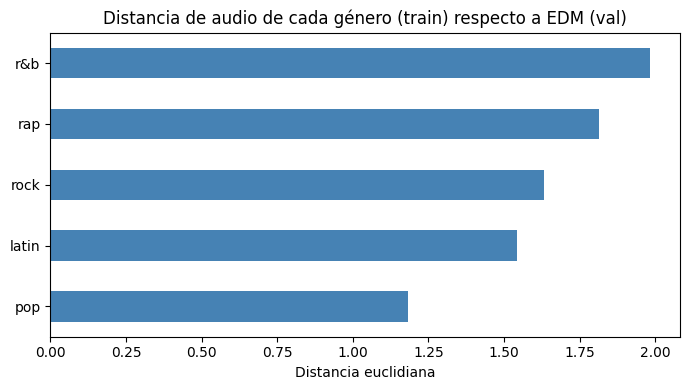

In [59]:
from sklearn.preprocessing import StandardScaler

audio_cols_dist = ['danceability','energy','key','loudness','mode','speechiness',
                    'acousticness','instrumentalness','liveness','valence','tempo']

scaler = StandardScaler()
all_audio = pd.concat([train[audio_cols_dist], val[audio_cols_dist]])
scaled = scaler.fit_transform(all_audio)
train_scaled = pd.DataFrame(scaled[:len(train)], columns=audio_cols_dist, index=train.index)
val_scaled   = pd.DataFrame(scaled[len(train):], columns=audio_cols_dist, index=val.index)

edm_profile = val_scaled[val['playlist_genre'].values=='edm'].mean()

distances = {}
for g in train['playlist_genre'].unique():
    g_profile = train_scaled[train['playlist_genre'].values==g].mean()
    distances[g] = np.sqrt(((g_profile - edm_profile)**2).sum())

dist_df = pd.Series(distances).sort_values()
print("Distancia euclidiana (en espacio de audio estandarizado) de cada género a EDM:")
print(dist_df.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
dist_df.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Distancia de audio de cada género (train) respecto a EDM (val)')
ax.set_xlabel('Distancia euclidiana')
plt.tight_layout()
plt.show()


### 2.10 Correlación entre features de audio y la popularidad

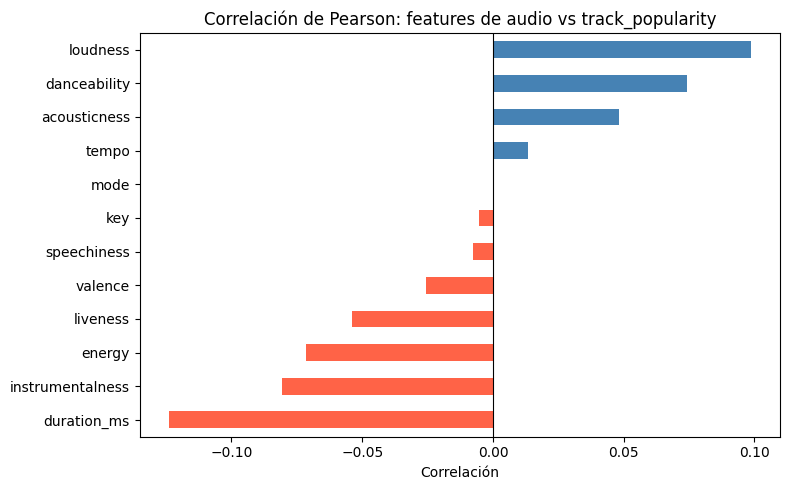

duration_ms        -0.124
instrumentalness   -0.081
energy             -0.072
liveness           -0.054
valence            -0.026
speechiness        -0.007
key                -0.005
mode                0.000
tempo               0.013
acousticness        0.048
danceability        0.074
loudness            0.099
Name: track_popularity, dtype: float64


In [60]:
audio_full = ['danceability','energy','key','loudness','mode','speechiness',
              'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']

corr_target = train[audio_full + ['track_popularity']].corr()['track_popularity'].drop('track_popularity').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_target]
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Pearson: features de audio vs track_popularity')
ax.set_xlabel('Correlación')
plt.tight_layout()
plt.show()

print(corr_target.round(3))


### 2.11 Matriz de correlación entre features de audio

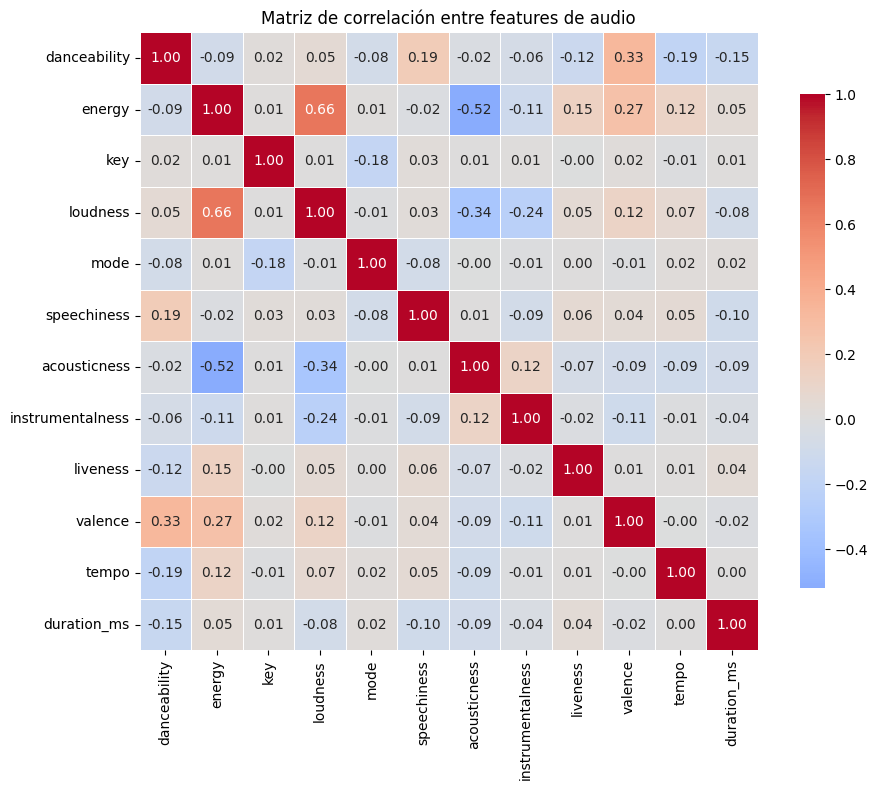

In [61]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = train[audio_full].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Matriz de correlación entre features de audio')
plt.tight_layout()
plt.show()


## 3. Feature Engineering

Construcción de las 28 features utilizadas por el modelo final: 12 de audio
original, 5 derivadas de la fecha de lanzamiento, 8 interacciones entre
features de audio, 2 de frecuencia (artista/álbum), y 1 indicadora de si el
género fue observado en entrenamiento.


In [62]:
def build_features(df_train):
    """
    Construye las features a partir del dataframe de entrenamiento.
    Todas las estadísticas (frecuencias, géneros observados) se calculan
    sobre df_train, sin ninguna dependencia de datos externos.
    """
    train_fe = df_train.copy()

    # Features de fecha
    train_fe['release_date_str'] = train_fe['track_album_release_date'].astype(str)
    train_fe['release_year_only'] = train_fe['release_date_str'].str.len() == 4
    train_fe['release_date_missing'] = train_fe['release_date_str'].isin(['nan','','None','0'])
    year_extracted = train_fe['release_date_str'].str[:4]
    train_fe['release_year'] = pd.to_numeric(year_extracted, errors='coerce')
    train_fe['release_year'] = train_fe['release_year'].where(
        train_fe['release_year'].between(1900, 2026), other=np.nan)
    train_fe['release_age_days'] = (2026 - train_fe['release_year']) * 365
    train_fe['release_jan1'] = train_fe['release_date_str'].str.endswith('-01-01')

    # Interacciones de audio
    train_fe['energy_x_loudness']         = train_fe['energy'] * train_fe['loudness'].abs()
    train_fe['valence_x_danceability']    = train_fe['valence'] * train_fe['danceability']
    train_fe['energy_minus_acousticness'] = train_fe['energy'] - train_fe['acousticness']
    train_fe['duration_min']              = train_fe['duration_ms'] / 60000
    train_fe['loudness_norm']       = (train_fe['loudness'] + 60) / 60
    train_fe['instrumental_energy'] = train_fe['instrumentalness'] * train_fe['energy']
    train_fe['dance_energy']        = train_fe['danceability'] * train_fe['energy']
    train_fe['acoustic_valence']    = train_fe['acousticness'] * train_fe['valence']

    # Frecuencias (calculadas sobre train, no usan el target)
    artist_count = df_train['track_artist'].value_counts().to_dict()
    train_fe['artist_freq'] = train_fe['track_artist'].map(artist_count).fillna(1)

    album_count = df_train['track_album_id'].value_counts().to_dict()
    train_fe['album_freq'] = train_fe['track_album_id'].map(album_count).fillna(1)

    # Meta-feature: el género siempre está "visto" dentro del propio train
    train_fe['genre_seen_in_train'] = 1

    return train_fe


train_fe = build_features(train)

AUDIO_COLS = ['danceability','energy','key','loudness','mode','speechiness',
              'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']
DATE_COLS = ['release_year','release_age_days','release_date_missing',
             'release_year_only','release_jan1']
INTERACTION_COLS = ['energy_x_loudness','valence_x_danceability',
                    'energy_minus_acousticness','duration_min']
FREQ_COLS = ['artist_freq','album_freq']
META_COLS = ['genre_seen_in_train']
NEW_COLS  = ['loudness_norm','instrumental_energy','dance_energy','acoustic_valence']

FEATURES = AUDIO_COLS + DATE_COLS + INTERACTION_COLS + FREQ_COLS + META_COLS + NEW_COLS

for col in ['release_date_missing','release_year_only','release_jan1']:
    train_fe[col] = train_fe[col].astype(int)

X = train_fe[FEATURES].replace([np.inf, -np.inf], np.nan)
y = train_fe['track_popularity'].reset_index(drop=True)

genre_groups  = train_fe['playlist_genre'].values
rb_mask_train = genre_groups == 'r&b'

print(f"Total de features: {len(FEATURES)}")
print(f"X shape: {X.shape}")


Total de features: 28
X shape: (26266, 28)


## 4. Imputación de valores faltantes

Se ajusta un `SimpleImputer` (estrategia: mediana) sobre el conjunto de
entrenamiento completo. Este mismo imputador se reutiliza para transformar
tanto los datos de entrenamiento como, posteriormente, los datos de test.


In [63]:
imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)
print("Imputador ajustado sobre el conjunto de entrenamiento.")


Imputador ajustado sobre el conjunto de entrenamiento.


## 5. Hiperparámetros del modelo y esquema de validación

Configuración seleccionada mediante validación cruzada con GroupKFold y
Grid Search (documentado en el notebook de exploración, no incluido en esta
entrega). Estos hiperparámetros son fijos y constituyen el modelo final.

Se define también `GroupKFold` (agrupando por género), el esquema de
validación utilizado tanto para el baseline como para el modelo final, de
manera que la comparación entre ambos sea directa y justa.


In [64]:
ET_PARAMS = dict(
    n_estimators=500,
    min_samples_leaf=2,
    max_features=0.7,
    random_state=SEED,
    n_jobs=-1,
)
print(f"Hiperparámetros del modelo: {ET_PARAMS}")

GKF = GroupKFold(n_splits=5)
print("Esquema de validación: GroupKFold(n_splits=5), agrupando por género.")


Hiperparámetros del modelo: {'n_estimators': 500, 'min_samples_leaf': 2, 'max_features': 0.7, 'random_state': 42, 'n_jobs': -1}
Esquema de validación: GroupKFold(n_splits=5), agrupando por género.


## 6. Modelo Baseline

Antes de entrenar el modelo final, se entrena un modelo baseline simple que
sirve como punto de referencia mínimo de performance. Un modelo final debe
superar claramente a este baseline para justificar su complejidad.

**Modelo baseline:** `DummyRegressor` con estrategia `mean` — predice
siempre el valor promedio de `track_popularity` observado en el conjunto de
entrenamiento, sin utilizar ninguna feature. Se valida con el mismo esquema
GroupKFold que el modelo final, para que la comparación sea directa.


In [65]:
baseline_pred_value = y.mean()
print(f"Predicción constante del baseline: {baseline_pred_value:.4f}")

oof_baseline = np.full(len(y), np.nan)
for tr_idx, vl_idx in GKF.split(X_imp, y, groups=genre_groups):
    m_base = DummyRegressor(strategy='mean')
    m_base.fit(X_imp[tr_idx], y.iloc[tr_idx])
    oof_baseline[vl_idx] = m_base.predict(X_imp[vl_idx])

r2_baseline   = r2_score(y, oof_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y, oof_baseline))

print(f"\n=== Performance del Baseline (GroupKFold) ===")
print(f"R²:   {r2_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print()
print("El baseline no utiliza ninguna feature de audio, fecha ni metadata —")
print("solo predice el promedio histórico. Sirve como piso de comparación:")
print("cualquier modelo con R² <= 0 no estaría aportando valor real.")


Predicción constante del baseline: 44.5433

=== Performance del Baseline (GroupKFold) ===
R²:   -0.0053
RMSE: 25.0579

El baseline no utiliza ninguna feature de audio, fecha ni metadata —
solo predice el promedio histórico. Sirve como piso de comparación:
cualquier modelo con R² <= 0 no estaría aportando valor real.


## 7. Modelo Final — Comparación con el Baseline

### 7.1 Modelo A — ExtraTrees general

Entrenado sobre el 100% del conjunto de entrenamiento. Predice las
observaciones cuyo género no fue observado en entrenamiento (en el conjunto
de test real, corresponde al género EDM).


In [66]:
oof_A = np.full(len(y), np.nan)
for tr_idx, vl_idx in GKF.split(X_imp, y, groups=genre_groups):
    m = ExtraTreesRegressor(**ET_PARAMS)
    m.fit(X_imp[tr_idx], y.iloc[tr_idx])
    oof_A[vl_idx] = np.clip(m.predict(X_imp[vl_idx]), 0, 100)

r2_A_all = r2_score(y, oof_A)
r2_A_rb  = r2_score(y[rb_mask_train], oof_A[rb_mask_train])
rmse_A   = np.sqrt(mean_squared_error(y, oof_A))

print(f"Modelo A — R² (GroupKFold, todas las filas):   {r2_A_all:.4f}")
print(f"Modelo A — R² (GroupKFold, solo filas de r&b):  {r2_A_rb:.4f}")
print(f"Modelo A — RMSE (GroupKFold, todas las filas):  {rmse_A:.4f}")

# Entrenamiento final del Modelo A sobre el 100% del train
model_A = ExtraTreesRegressor(**ET_PARAMS)
model_A.fit(X_imp, y)
print("\nModelo A entrenado sobre el conjunto de entrenamiento completo "
      f"({X_imp.shape[0]} filas, {X_imp.shape[1]} features).")


Modelo A — R² (GroupKFold, todas las filas):   0.2764
Modelo A — R² (GroupKFold, solo filas de r&b):  0.3641
Modelo A — RMSE (GroupKFold, todas las filas):  21.2589

Modelo A entrenado sobre el conjunto de entrenamiento completo (26266 filas, 28 features).


### 7.2 Modelo B — ExtraTrees especializado en r&b

Entrenado únicamente sobre las observaciones de género r&b del conjunto de
entrenamiento. Predice, en combinación con el Modelo A, las observaciones de
r&b en el conjunto de test.


In [67]:
X_rb = X_imp[rb_mask_train]
y_rb = y[rb_mask_train].reset_index(drop=True)

# Validación con KFold (un solo género, no aplica GroupKFold)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_B = np.full(len(y_rb), np.nan)
for tr_idx, vl_idx in kf.split(X_rb):
    m = ExtraTreesRegressor(**ET_PARAMS)
    m.fit(X_rb[tr_idx], y_rb.iloc[tr_idx])
    oof_B[vl_idx] = np.clip(m.predict(X_rb[vl_idx]), 0, 100)

r2_B_rb  = r2_score(y_rb, oof_B)
rmse_B   = np.sqrt(mean_squared_error(y_rb, oof_B))

print(f"Modelo B — R² (KFold, solo r&b):   {r2_B_rb:.4f}")
print(f"Modelo B — RMSE (KFold, solo r&b): {rmse_B:.4f}")

# Entrenamiento final del Modelo B sobre el 100% de las filas de r&b
model_B = ExtraTreesRegressor(**ET_PARAMS)
model_B.fit(X_rb, y_rb)
print(f"\nModelo B entrenado sobre las observaciones de r&b "
      f"({X_rb.shape[0]} filas, {X_rb.shape[1]} features).")


Modelo B — R² (KFold, solo r&b):   0.4222
Modelo B — RMSE (KFold, solo r&b): 19.6106

Modelo B entrenado sobre las observaciones de r&b (4907 filas, 28 features).


## 8. Comparación final: Baseline vs. Modelo Final


In [68]:
print("="*55)
print(f"{'Modelo':<35}{'R²':>10}{'RMSE':>10}")
print("="*55)
print(f"{'Baseline (DummyRegressor, mean)':<35}{r2_baseline:>10.4f}{rmse_baseline:>10.4f}")
print(f"{'Modelo A (general, todas las filas)':<35}{r2_A_all:>10.4f}{rmse_A:>10.4f}")
print(f"{'Modelo A en filas de r&b':<35}{r2_A_rb:>10.4f}{'':>10}")
print(f"{'Modelo B (especializado en r&b)':<35}{r2_B_rb:>10.4f}{rmse_B:>10.4f}")
print("="*55)
print()
print(f"Mejora del Modelo A sobre el Baseline:        +{r2_A_all - r2_baseline:.4f} de R²")
print(f"Mejora de la especialización en r&b (B vs A): +{r2_B_rb - r2_A_rb:.4f} de R²")
print()
print("El modelo final supera ampliamente al baseline, confirmando que las")
print("features de audio, fecha y metadata aportan información real para")
print("predecir la popularidad, más allá de simplemente predecir el promedio.")


Modelo                                     R²      RMSE
Baseline (DummyRegressor, mean)       -0.0053   25.0579
Modelo A (general, todas las filas)    0.2764   21.2589
Modelo A en filas de r&b               0.3641          
Modelo B (especializado en r&b)        0.4222   19.6106

Mejora del Modelo A sobre el Baseline:        +0.2817 de R²
Mejora de la especialización en r&b (B vs A): +0.0581 de R²

El modelo final supera ampliamente al baseline, confirmando que las
features de audio, fecha y metadata aportan información real para
predecir la popularidad, más allá de simplemente predecir el promedio.


## Resumen

Al ejecutar este notebook de principio a fin, quedan disponibles en memoria:

- `model_A`: ExtraTreesRegressor entrenado sobre el 100% del conjunto de
  entrenamiento (26.266 filas, 28 features).
- `model_B`: ExtraTreesRegressor entrenado sobre las 4.907 filas de r&b del
  conjunto de entrenamiento.
- `imp`: `SimpleImputer` ajustado sobre el conjunto de entrenamiento, a
  reutilizar para transformar los datos de test de forma consistente.
- `FEATURES`: lista ordenada de las 28 columnas utilizadas como input.

El modelo final (Modelo A + Modelo B) supera claramente al baseline,
validando que el enfoque de feature engineering y especialización por
género aporta valor real sobre una predicción ingenua del promedio.

El notebook `aplicar_modelo_test.ipynb` reproduce estos mismos pasos
(idéntica semilla, idénticos hiperparámetros, idéntico feature engineering,
misma versión de scikit-learn) y los aplica sobre el conjunto de test para
generar el archivo de submission.
